# SWGO L07 Detector Optimization (Refactored)

All utility functions have been extracted into separate Python modules.
This notebook preserves the original optimization logic.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Standard library imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import copy
import warnings
import matplotlib.patches as patches
from pathlib import Path
from matplotlib import colors
from matplotlib.colors import LogNorm, Normalize
from torch.utils.data import TensorDataset, DataLoader
import os
import gc

# Extracted module imports
from modules.generate_showers import GenerateShowers
from modules.shower_computation import ComputeShowerDetection
from modules.detector_response import GetCounts_differentiable, SmearN, TimeAverage_vectorized
from modules.geometry import Layouts
from modules.reconstruction import Reconstruction, NormalizeLabels, DenormalizeLabels, EarlyStopping
from modules.layout_optimization import LearnableXY, push_apart, symmetry_loss
from modules.utility_functions import reconstructability, U_PR, U_E, U_angle

output_dir = "./outputs/NN_Files_31_20k_small_start"
os.makedirs(output_dir, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generate_new_data = True

## Constants and Parameters

In [3]:
# Matrices used in shower parametrization
A = torch.tensor([[1, 1, 1, 1],[1, 2, 4, 8], [1, 3, 9, 27], [1, 4, 16, 64]], dtype=torch.float32)

# Constants
c0 = .29979  # Speed of light in [m / ns]
theta_max = np.pi * 65 / 180
log_01 = torch.tensor([np.log(.1)], dtype=torch.float32)
log_10 = torch.tensor([np.log(10)], dtype=torch.float32)
sqrt12 = torch.tensor([np.sqrt(12)], dtype=torch.float32)

# Tank Values
IntegrationWindow = 128.  # 128 ns integration window, SWGO default
sigma_time = 10.  # Time resolution assumed for the detectors
R_min = 2.
TankArea = 6.859 * np.pi  # Area for 19 hexagonal macro unit
TankRadius = np.sqrt(6.859)  # Radius of macro unit

# Background
Bgr_mu_per_m2 = 0.000001826 * IntegrationWindow
fluxB_m = torch.tensor([TankArea * Bgr_mu_per_m2])
Bgr_e_per_m2 = 0.000000200 * IntegrationWindow
fluxB_e = torch.tensor([TankArea * Bgr_e_per_m2])

# Sizes
Nunits = 90 # 500
n_rings = 5 #20
RelResCounts = .05

# Debug Parameters
largenumber = 1e13
epsilon = 1 / largenumber

# NN
Nevents = 20000#200000
Nvalidation = 2000#20000
Ntest = 300#3000

# Layout
SWGOopt = False

x_det, y_det = Layouts(n_detectors=Nunits, n_rings=n_rings, radius=300, center=(0,0), device=device)


## Initialize Diffusion Model

In [4]:
generate_showers_instance = GenerateShowers(output_dir=output_dir, device=device, batch_size=60)

## Helper: Wrap GenerateShowers with module dependencies

In [5]:
# Create wrapped versions that capture the global dependencies
import functools

_SmearN = functools.partial(SmearN, RelResCounts=RelResCounts)
_TimeAverage = functools.partial(TimeAverage_vectorized,
                                  IntegrationWindow=IntegrationWindow,
                                  sigma_time=sigma_time)
_GetCounts = functools.partial(GetCounts_differentiable,
                                SmearN_fn=_SmearN,
                                fluxB_e=fluxB_e,
                                TimeAverage_vectorized_fn=_TimeAverage)

def generate_showers(x_det, y_det, log=False, number_of_showers=1, device=device, use_cache=False):
    return ComputeShowerDetection(x_det, y_det, generate_showers_instance, _GetCounts,
                           log=log, number_of_showers=number_of_showers, device=device, 
                           use_cache=use_cache, output_dir=output_dir)

## Visualize Initial Layout

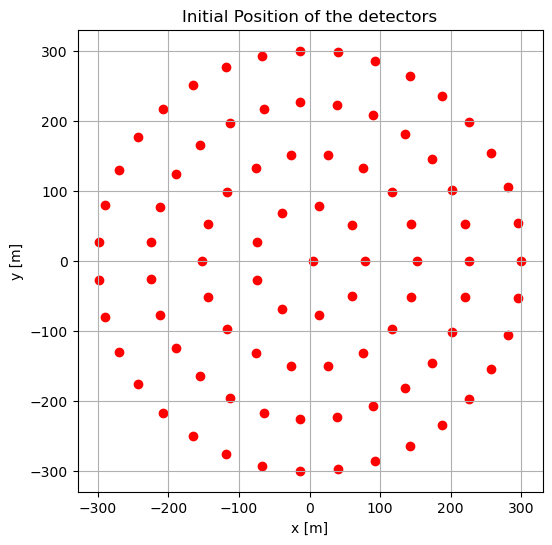

In [6]:
plt.figure(figsize=[6, 6])
plt.scatter(x_det.cpu().detach(), y_det.cpu().detach(), color="red")
plt.grid()
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Initial Position of the detectors")
# plt.xlim((-50, 650))
# plt.ylim((-350, 350))
plt.show()

## Generate and Visualize a Single Shower

  Loading PointCountFM from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/num_of_point_clouds_dequantize_compiled.pt ...
  Loaded in 1117.9 ms
  Running inference on 10 samples ...
  Inference done in 1.05 s
  Mean total hits predicted per shower: 1999.9
  Loading AllShowers generator from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/all_showers ...
  Loaded in 0.15 s
  Time mode: ON (x,y,e,t)
  Generating 10 showers (16 ODE steps, solver=midpoint, device=cuda) ...
[     0s]: start batch   0


/n/home05/zdimitrov/.conda/envs/multiproc_env/lib/python3.13/site-packages/torch/_inductor/compile_fx.py:312: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


[    57s]: generation done
  Generation done in 57.14 s
samples shape: torch.Size([10, 2048, 5])
  Saved 10 showers → ./outputs/NN_Files_31_20k_small_start/cashed_showers_10.pt


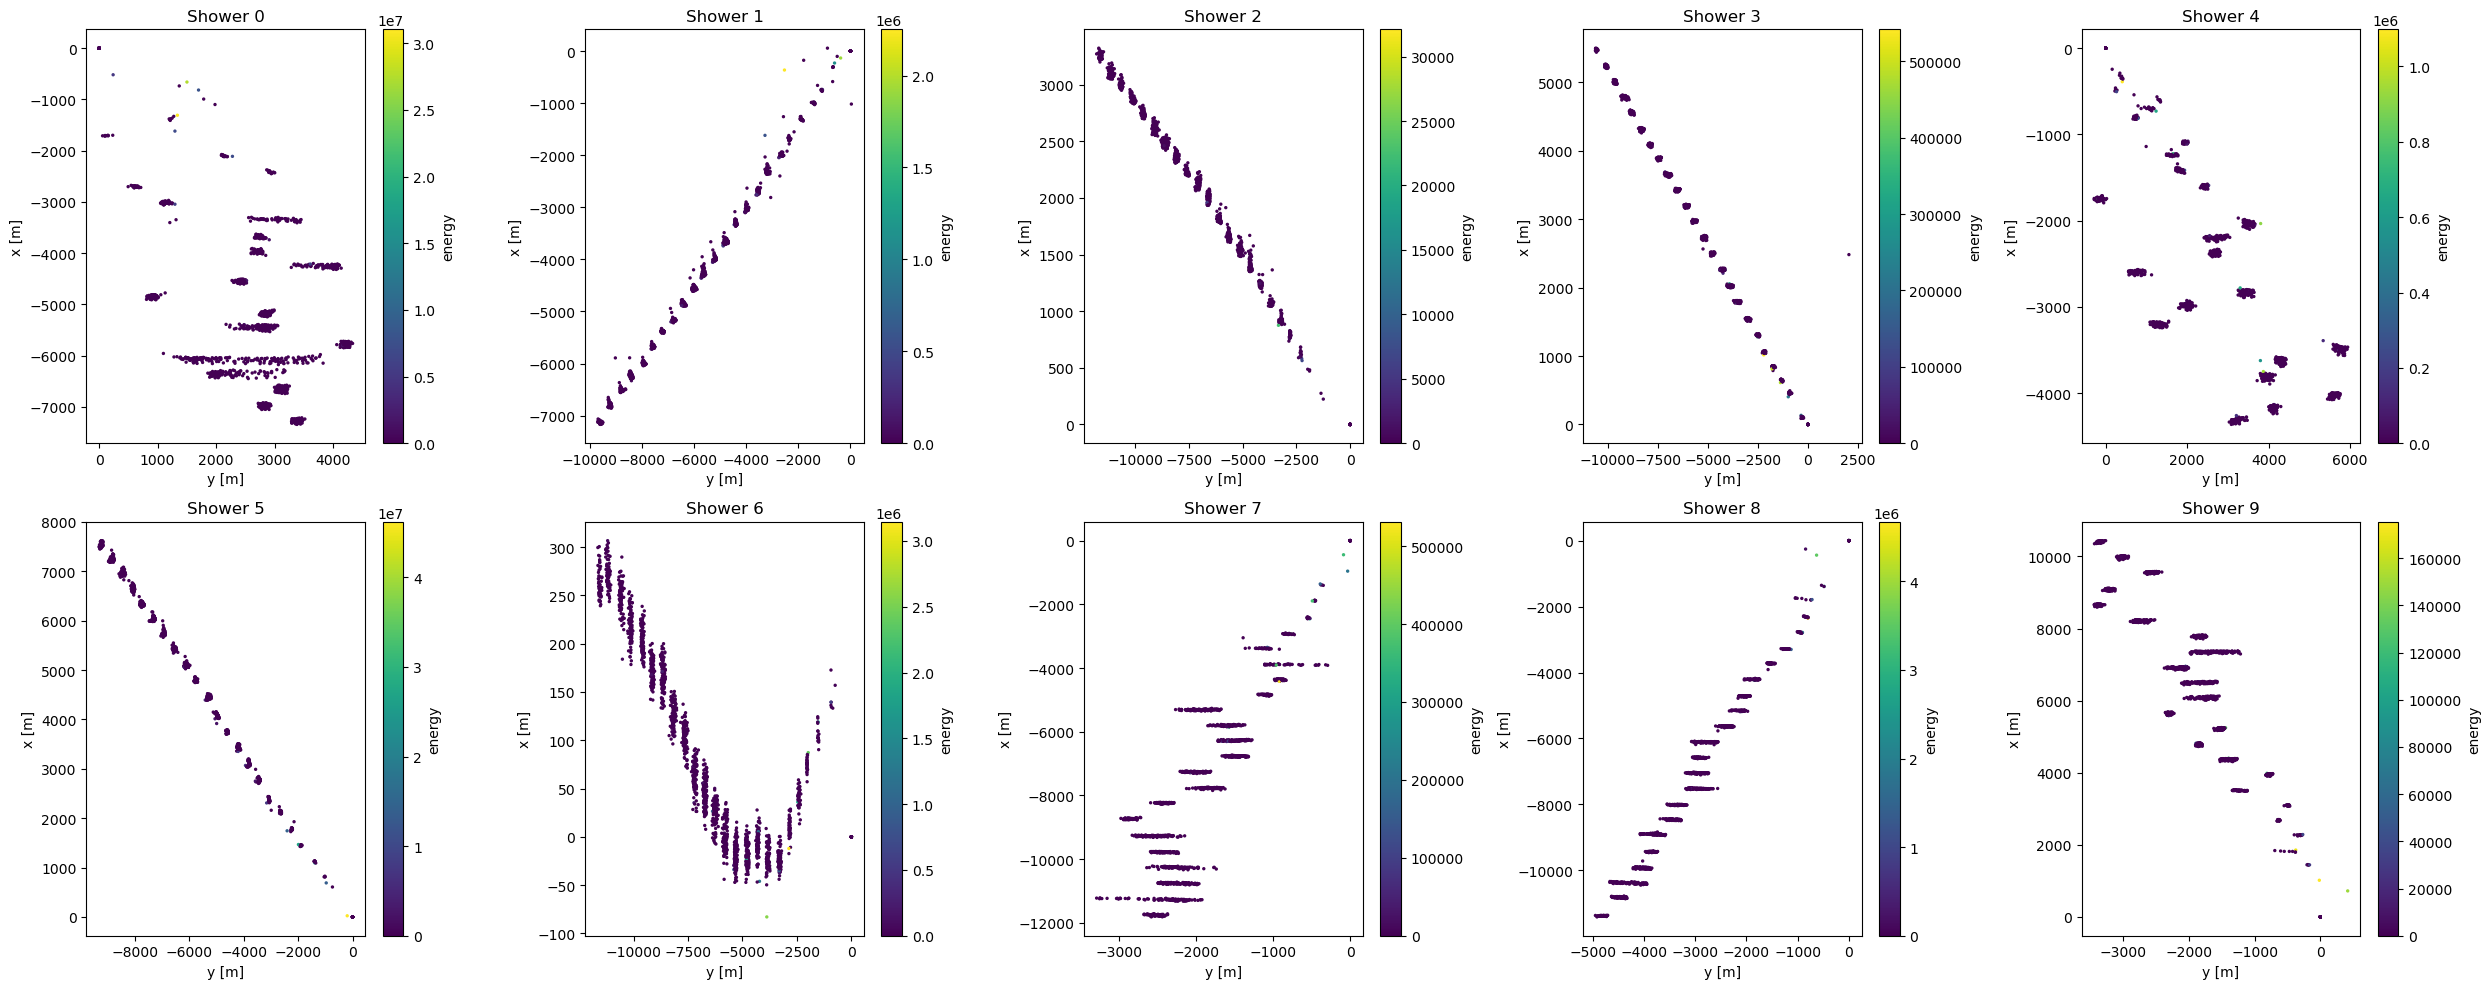

In [7]:
SWGOopt = False
with torch.no_grad():
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, labels = generate_showers(x_det, y_det, True, number_of_showers=10, use_cache=True)

In [8]:
print("N:", N.shape)
print("T:", T.shape)
print("X0:", X0)
print("Y0:", Y0)
print("E:", energy.shape)

N: torch.Size([10, 90])
T: torch.Size([10, 90])
X0: tensor([-2157.5188, -1875.6666,  1450.6866,  1675.3130, -2149.8154,  1680.2216,
           22.0309, -4097.5757, -3101.7019,  4034.9185], device='cuda:0')
Y0: tensor([ 1835.1804, -2882.2554, -5023.2554, -3314.9832,  2281.5459, -2205.0303,
        -4069.6016, -1046.4846, -1303.4474, -1140.4800], device='cuda:0')
E: torch.Size([10])


In [9]:
N[0]

tensor([7.9586e+04, 2.8270e+04, 4.8644e+04, 1.0478e+05, 1.9731e+05, 2.4156e+05,
        1.7489e+05, 8.7105e+04, 4.1350e+04, 2.6513e+04, 8.7654e+03, 1.3503e+04,
        2.5073e+04, 5.2081e+04, 1.1080e+05, 2.2043e+05, 3.7742e+05, 5.2124e+05,
        5.5846e+05, 4.6034e+05, 2.9882e+05, 1.6093e+05, 7.7476e+04, 3.6416e+04,
        1.8305e+04, 1.0691e+04, 7.7412e+03, 7.2253e+03, 2.3722e+03, 3.5107e+03,
        5.9600e+03, 1.1281e+04, 2.2999e+04, 4.8606e+04, 1.0227e+05, 2.0583e+05,
        3.8156e+05, 6.3017e+05, 9.0252e+05, 1.0994e+06, 1.1270e+06, 9.7088e+05,
        7.0860e+05, 4.4565e+05, 2.4763e+05, 1.2548e+05, 6.0150e+04, 2.8379e+04,
        1.3723e+04, 7.0731e+03, 4.0270e+03, 2.6107e+03, 1.9729e+03, 1.7642e+03,
        1.8781e+03, 5.6039e+02, 8.2251e+02, 1.3515e+03, 2.4468e+03, 4.7883e+03,
        9.9132e+03, 2.1209e+04, 4.5762e+04, 9.7143e+04, 1.9804e+05, 3.7894e+05,
        6.6651e+05, 1.0583e+06, 1.4944e+06, 1.8561e+06, 2.0137e+06, 1.9033e+06,
        1.5700e+06, 1.1373e+06, 7.3103e+

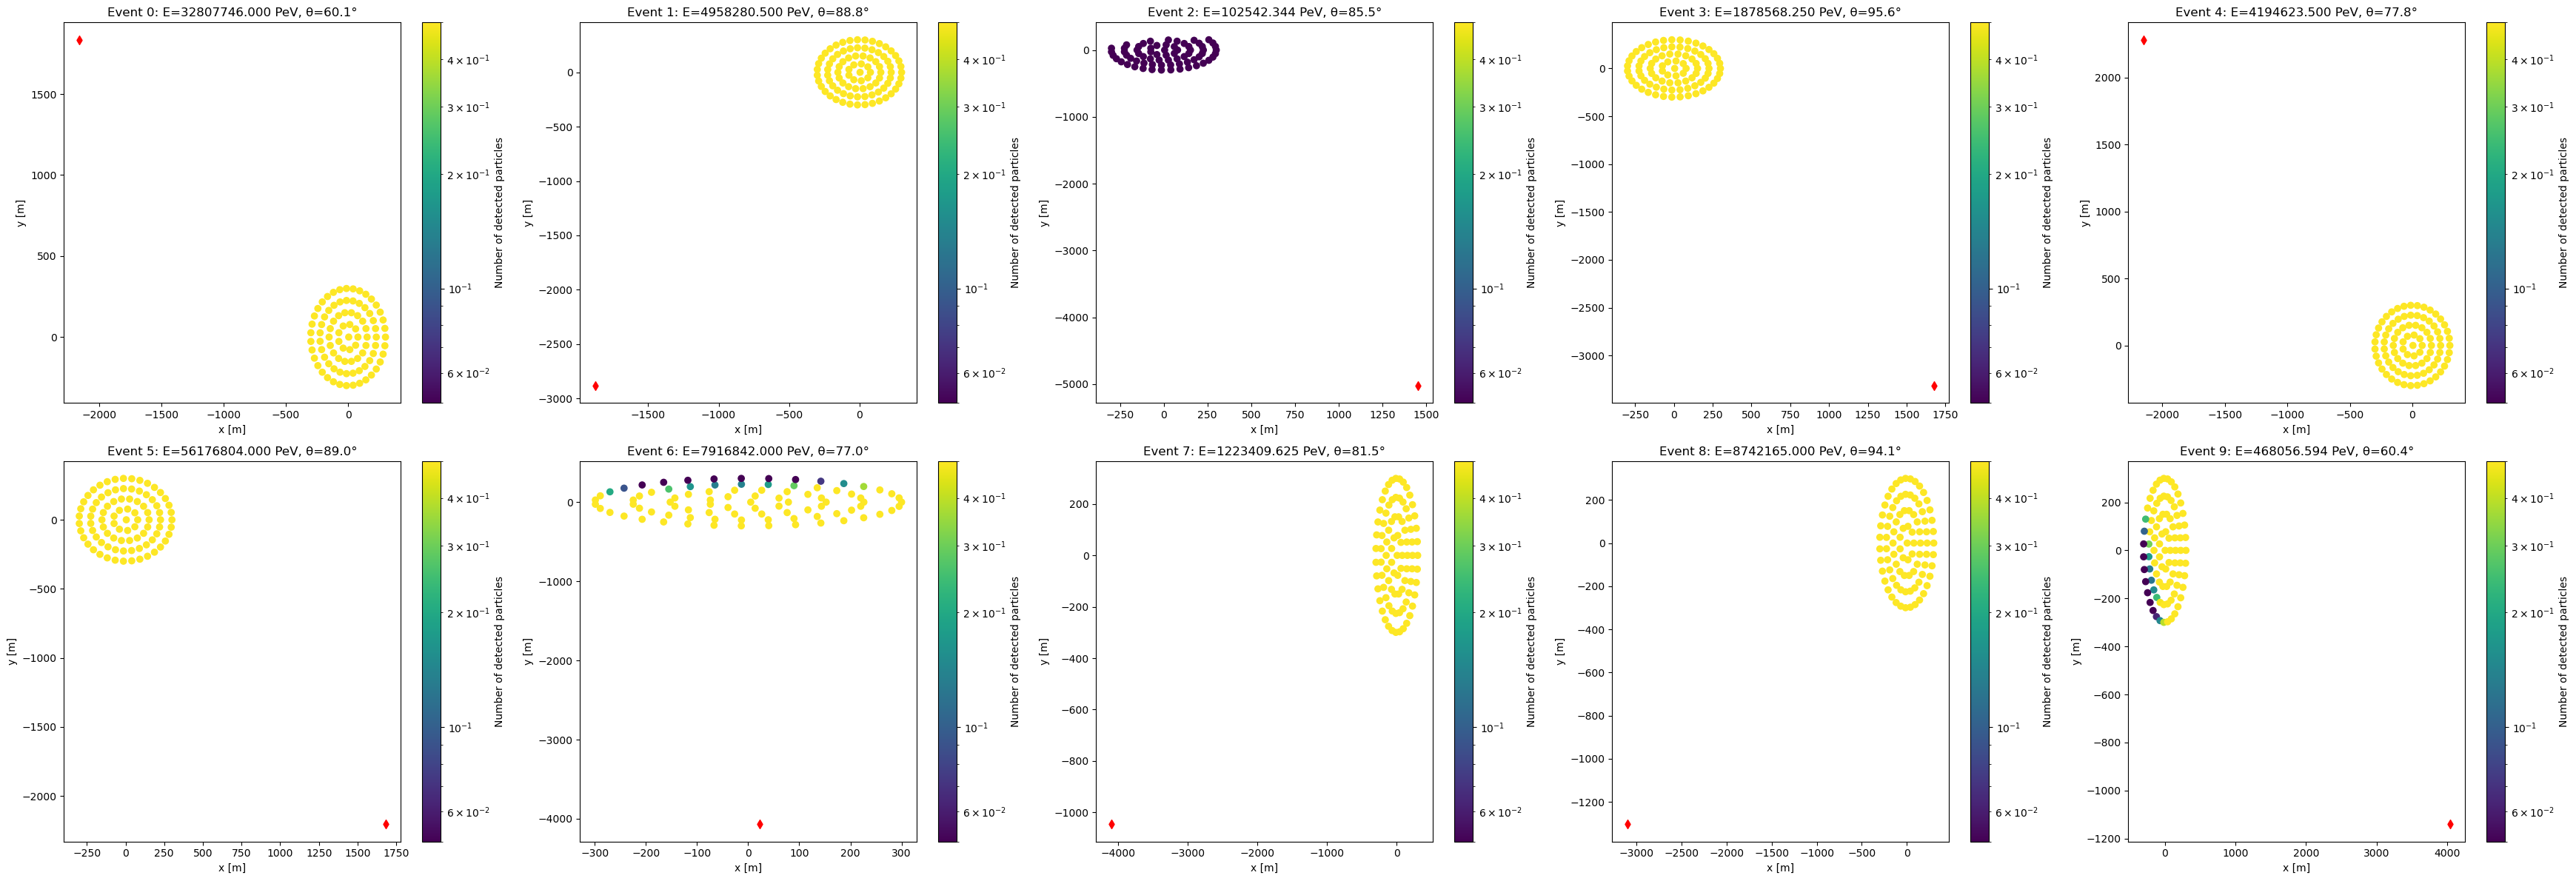

In [10]:
th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

n_events = N.shape[0]
ncols = 5
nrows = (n_events + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes  = axes.flatten()

for i in range(n_events):
    N_tmp = N[i]
    idx = torch.where(N_tmp >= 5e-9)[0]
    norm = LogNorm(vmin=5e-2, vmax=5e-1)

    scatter = axes[i].scatter(x_det[idx].detach().cpu(), y_det[idx].detach().cpu(), c=N_tmp[idx].detach().cpu(), cmap="viridis", norm=norm)
    axes[i].scatter(X0[i].item(), Y0[i].item(), c="red", marker="d")
    fig.colorbar(scatter, ax=axes[i], label='Number of detected particles')
    axes[i].set_xlabel("x [m]"); axes[i].set_ylabel("y [m]")
    # axes[i].set_xlim((-50, 650)); axes[i].set_ylim((-350, 350))
    axes[i].set_title(f"Event {i}: E={energy[i].item():.3f} PeV, θ={th[i].item()*180/np.pi:.1f}°")

for i in range(n_events, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

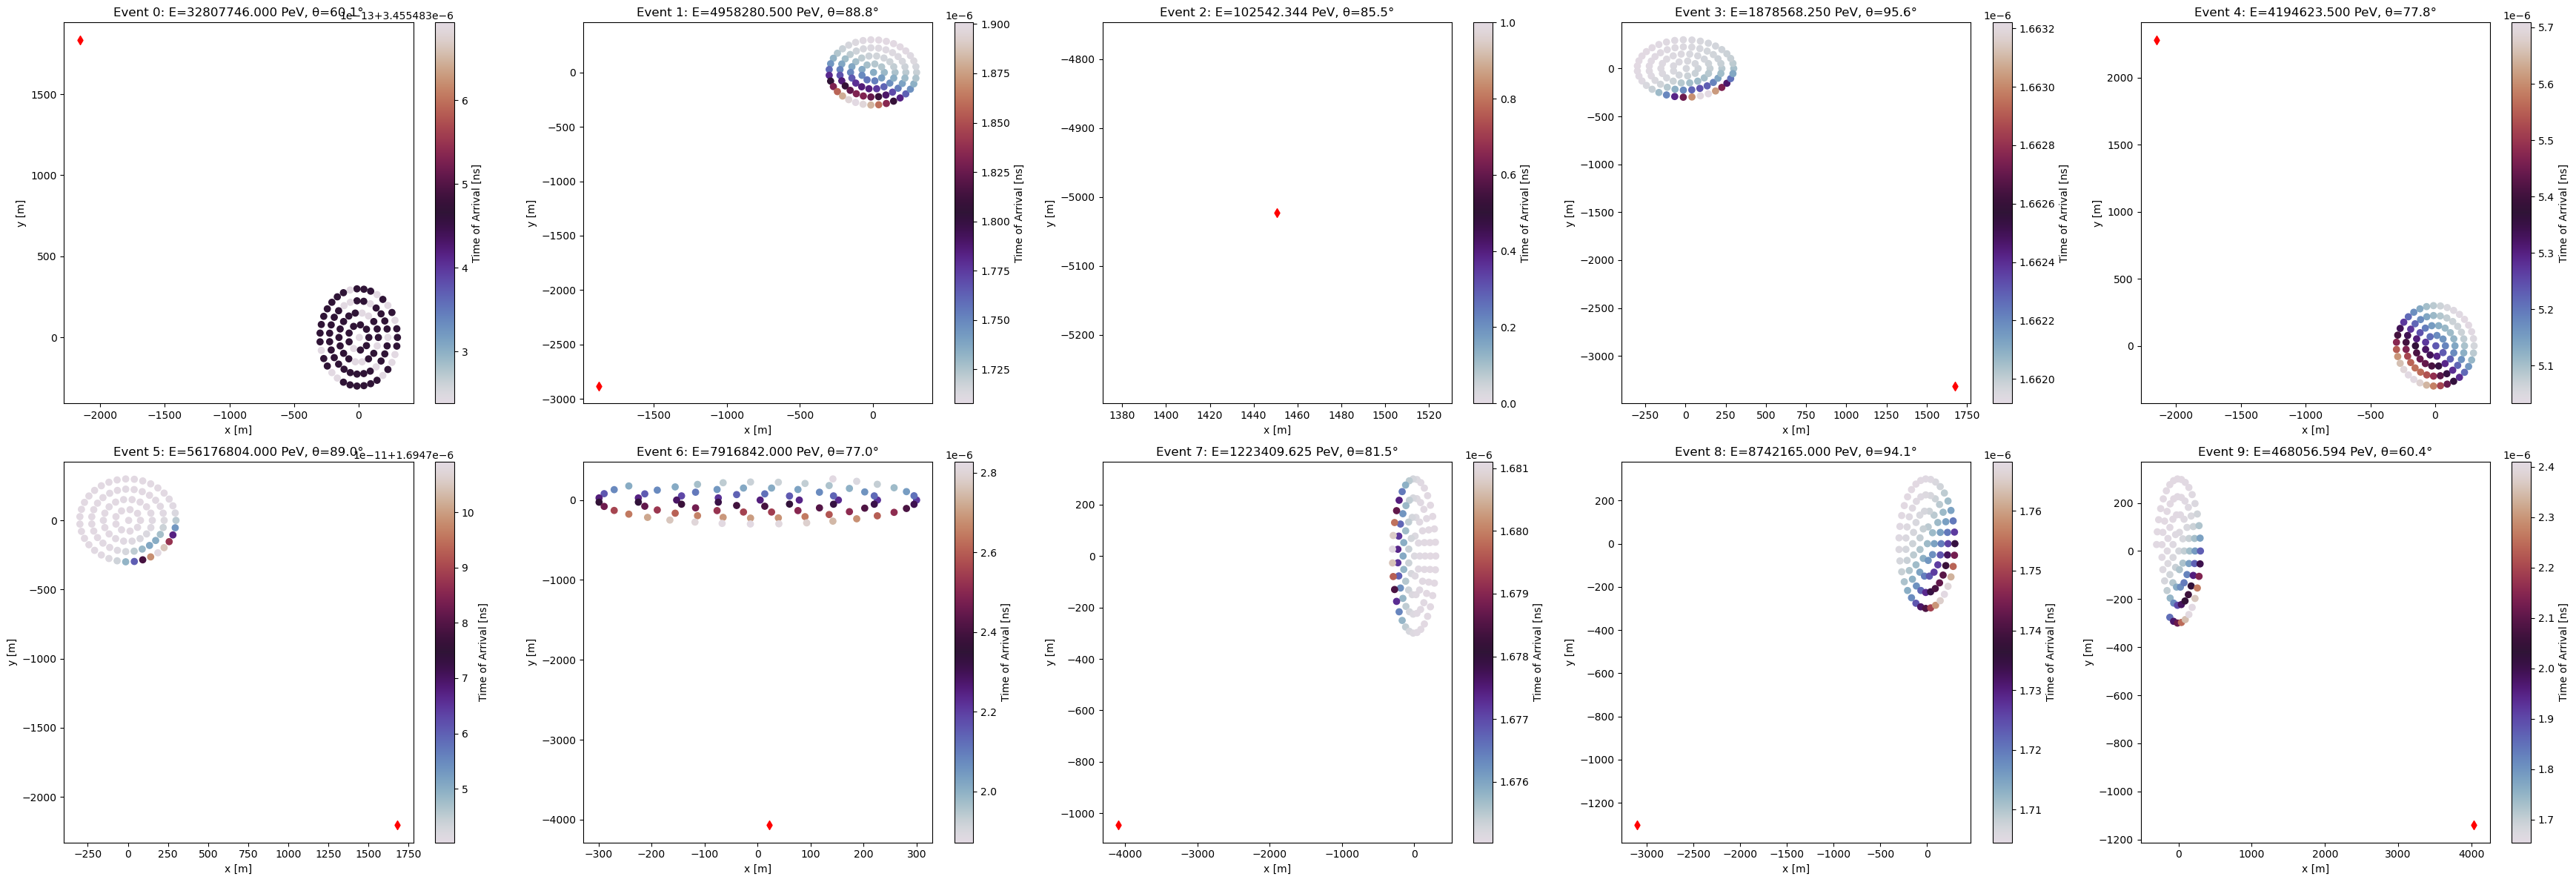

In [11]:
th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

n_events = N.shape[0]
ncols = 5
nrows = (n_events + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes  = axes.flatten()

for i in range(n_events):
    N_tmp = N[i]
    T_tmp = T[i]
    idx = torch.where(N_tmp >= 5e-2)[0]
    from matplotlib.colors import SymLogNorm
    # norm = SymLogNorm(linthresh=1, vmin=-1, vmax=1)


    scatter = axes[i].scatter(x_det[idx].detach().cpu(), y_det[idx].detach().cpu(), c=T_tmp[idx].detach().cpu(), cmap="twilight")
    
    axes[i].scatter(X0[i].item(), Y0[i].item(), c="red", marker="d")
    fig.colorbar(scatter, ax=axes[i], label='Time of Arrival [ns]')
    axes[i].set_xlabel("x [m]"); axes[i].set_ylabel("y [m]")
    # axes[i].set_xlim((-50, 650)); axes[i].set_ylim((-350, 350))
    axes[i].set_title(f"Event {i}: E={energy[i].item():.3f} PeV, θ={th[i].item()*180/np.pi:.1f}°")

for i in range(n_events, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

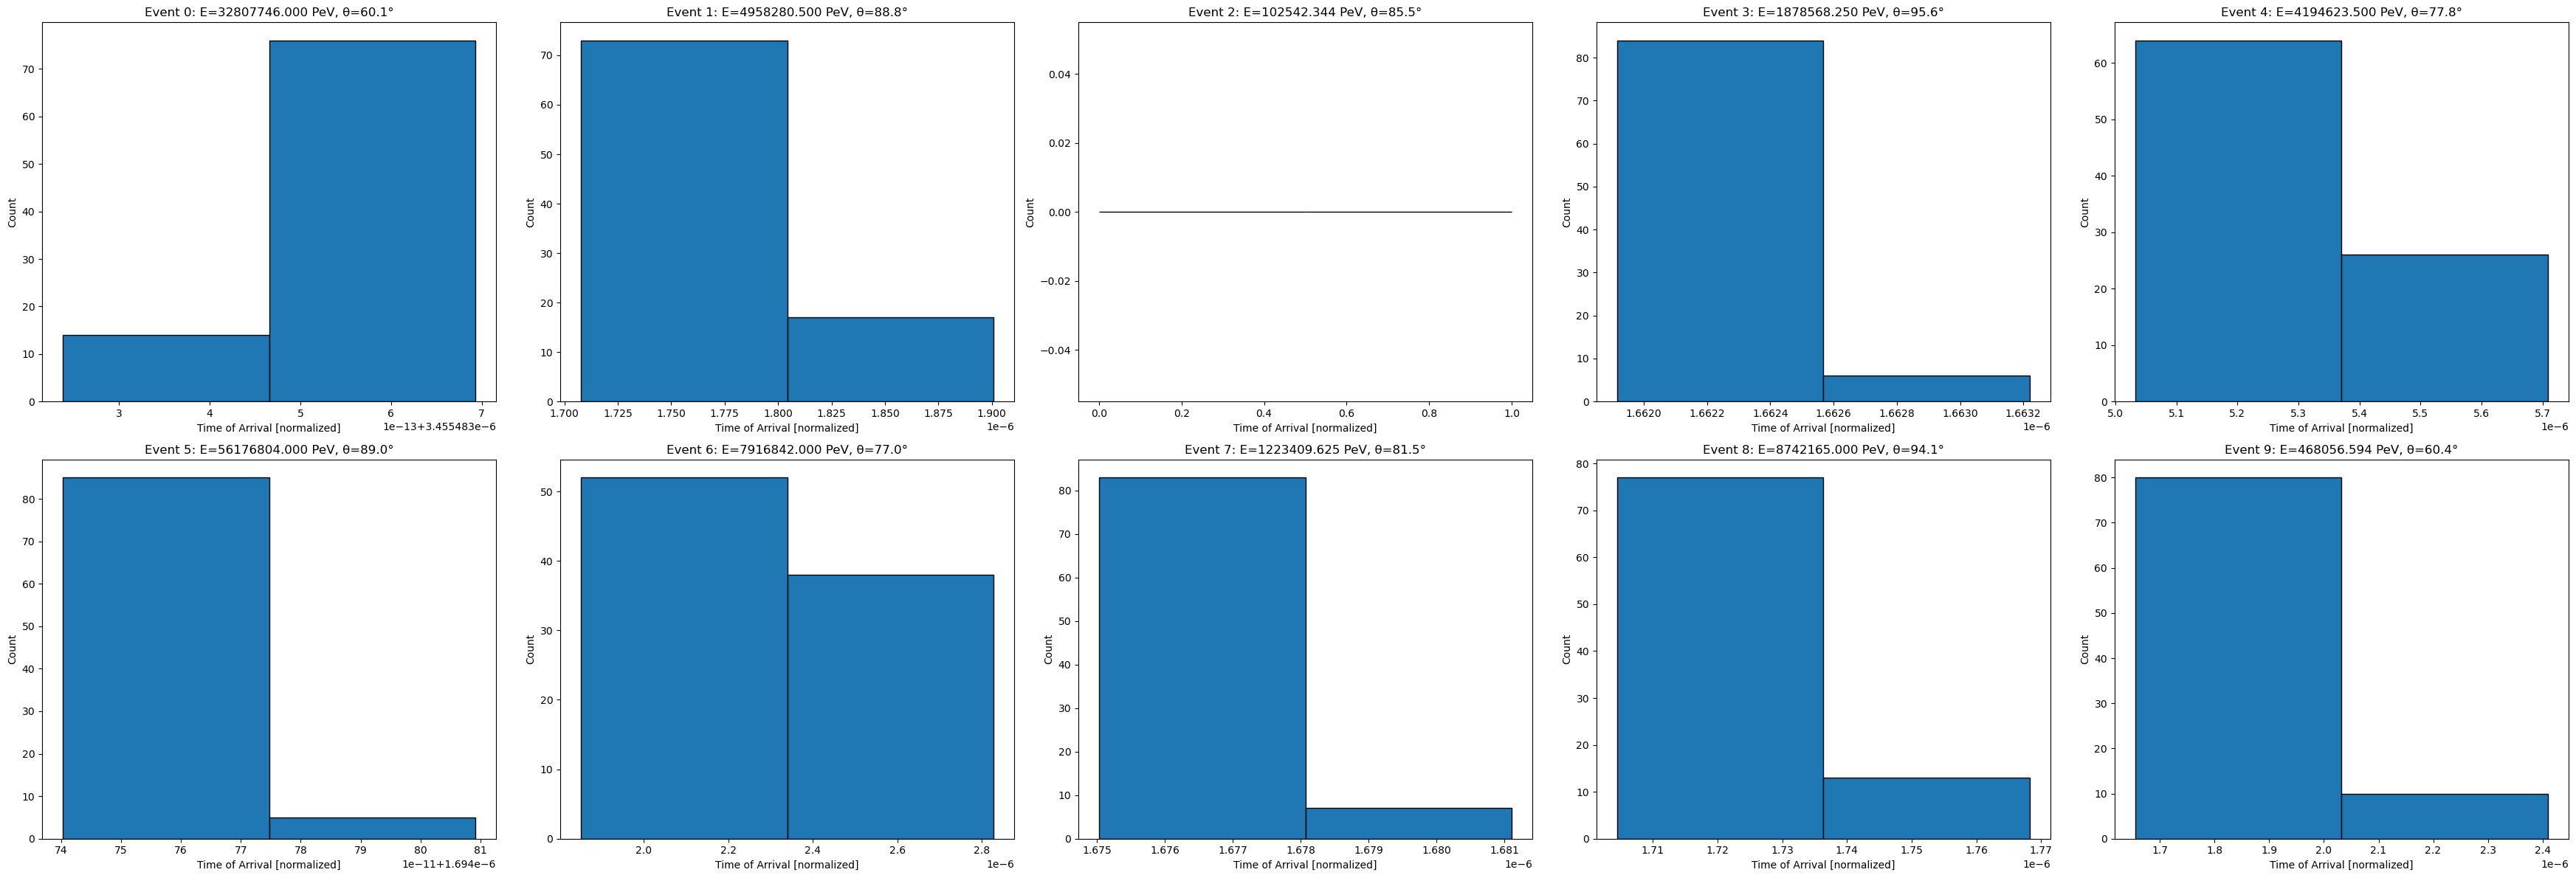

In [ ]:
th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

n_events = N.shape[0]
ncols = 5
nrows = (n_events + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes = axes.flatten()

for i in range(n_events):
    N_tmp = N[i]
    T_tmp = T[i]
    idx = torch.where(N_tmp >= 5e-3)[0]
    axes[i].hist(T_tmp[idx].detach().cpu().numpy(), bins=2, edgecolor='black')
    axes[i].set_xlabel("Time of Arrival [normalized]")
    axes[i].set_ylabel("Count")
    axes[i].set_title(f"Event {i}: E={energy[i].item():.3f} PeV, θ={th[i].item()*180/np.pi:.1f}°")

for i in range(n_events, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


## Generate Training Data

In [15]:
print(f"energy.min(): {energy.min()}, energy.max(): {energy.max()}")
print(f"theta.min(): {th.min()}, theta.max(): {th.max()}")
print(f"phi.min(): {ph.min()}, phi.max(): {ph.max()}")

energy.min(): 102542.34375, energy.max(): 56176804.0
theta.min(): 1.0485079288482666, theta.max(): 1.6680734157562256
phi.min(): -2.9569461345672607, phi.max(): 2.3471970558166504


In [16]:
%%time

if generate_new_data:
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(x_det, y_det, False, number_of_showers=Nevents, use_cache=True)

    th = torch.atan2(sin_z, cos_z)
    ph = torch.atan2(sin_a, cos_a)

    E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
    x0 = X0 / 5000
    y0 = Y0 / 5000

    x_det_exp = x_det.unsqueeze(0).expand(Nevents, -1)
    y_det_exp = y_det.unsqueeze(0).expand(Nevents, -1)

    x0_exp = x0.unsqueeze(1).expand(-1, Nunits)
    y0_exp = y0.unsqueeze(1).expand(-1, Nunits)

    inputs = torch.stack([x_det_exp, y_det_exp, N, T, x0_exp, y0_exp], dim=2).float()
    labels = torch.stack([E_norm, theta_norm, phi_norm], dim=1).float()

    os.makedirs(output_dir, exist_ok=True)
    torch.save(inputs, f"{output_dir}/inputs.pt")
    torch.save(labels, f"{output_dir}/labels.pt")

  Loading PointCountFM from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/num_of_point_clouds_dequantize_compiled.pt ...
  Loaded in 827.8 ms
  Running inference on 20000 samples ...
  Inference done in 24.82 s
  Mean total hits predicted per shower: 1991.5
  Loading AllShowers generator from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/all_showers ...
  Loaded in 0.05 s
  Time mode: ON (x,y,e,t)
  Generating 20000 showers (16 ODE steps, solver=midpoint, device=cuda) ...
[   158s]: start batch   0
[   194s]: start batch   1
[   195s]: start batch   2
[   196s]: start batch   3
[   197s]: start batch   4
[   197s]: start batch   5
[   198s]: start batch   6
[   199s]: start batch   7
[   200s]: start batch   8
[   200s]: start batch   9
[   201s]: start batch  10
[   202s]: start batch  11
[   203s]: start batch  12
[   204s]: start batch  13
[   204s]: start batch  14
[   205s]: start batch  15
[   206s]: start batch  16
[   207s]: start batch  17
[   208s]: 

/n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/generator.py:150: UserWarning: num points 2537 exceeds max points 2048, truncating
  warnings.warn(


[   288s]: start batch 119
[   288s]: start batch 120
[   289s]: start batch 121
[   290s]: start batch 122
[   291s]: start batch 123
[   292s]: start batch 124
[   292s]: start batch 125
[   293s]: start batch 126
[   294s]: start batch 127
[   295s]: start batch 128
[   295s]: start batch 129
[   296s]: start batch 130
[   297s]: start batch 131
[   298s]: start batch 132
[   299s]: start batch 133
[   299s]: start batch 134
[   300s]: start batch 135
[   301s]: start batch 136
[   302s]: start batch 137
[   303s]: start batch 138
[   303s]: start batch 139
[   304s]: start batch 140
[   305s]: start batch 141
[   306s]: start batch 142
[   307s]: start batch 143
[   307s]: start batch 144
[   308s]: start batch 145
[   309s]: start batch 146
[   310s]: start batch 147
[   311s]: start batch 148
[   311s]: start batch 149
[   312s]: start batch 150
[   313s]: start batch 151
[   314s]: start batch 152
[   315s]: start batch 153
[   315s]: start batch 154
[   316s]: start batch 155
[

/n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/generator.py:150: UserWarning: num points 2053 exceeds max points 2048, truncating
  warnings.warn(


[   391s]: start batch 250
[   392s]: start batch 251
[   393s]: start batch 252
[   394s]: start batch 253
[   395s]: start batch 254
[   395s]: start batch 255
[   396s]: start batch 256
[   397s]: start batch 257
[   398s]: start batch 258
[   398s]: start batch 259
[   399s]: start batch 260
[   400s]: start batch 261
[   401s]: start batch 262
[   402s]: start batch 263
[   402s]: start batch 264
[   403s]: start batch 265
[   404s]: start batch 266
[   405s]: start batch 267
[   406s]: start batch 268
[   406s]: start batch 269
[   407s]: start batch 270
[   408s]: start batch 271
[   409s]: start batch 272
[   410s]: start batch 273
[   410s]: start batch 274
[   411s]: start batch 275
[   412s]: start batch 276
[   413s]: start batch 277


/n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/generator.py:150: UserWarning: num points 2143 exceeds max points 2048, truncating
  warnings.warn(


[   413s]: start batch 278
[   414s]: start batch 279
[   415s]: start batch 280
[   416s]: start batch 281
[   417s]: start batch 282
[   417s]: start batch 283
[   418s]: start batch 284
[   419s]: start batch 285
[   420s]: start batch 286
[   421s]: start batch 287
[   421s]: start batch 288
[   422s]: start batch 289
[   423s]: start batch 290
[   424s]: start batch 291
[   425s]: start batch 292
[   425s]: start batch 293
[   426s]: start batch 294
[   427s]: start batch 295
[   428s]: start batch 296
[   428s]: start batch 297
[   429s]: start batch 298
[   430s]: start batch 299
[   431s]: start batch 300
[   432s]: start batch 301
[   432s]: start batch 302
[   433s]: start batch 303
[   434s]: start batch 304
[   435s]: start batch 305
[   436s]: start batch 306
[   436s]: start batch 307
[   437s]: start batch 308
[   438s]: start batch 309
[   439s]: start batch 310
[   440s]: start batch 311
[   440s]: start batch 312
[   441s]: start batch 313
[   442s]: start batch 314
[

## Generate Validation Data

In [17]:
%%time

if generate_new_data:
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(x_det, y_det, False, number_of_showers=Nvalidation, use_cache=True)

    th = torch.atan2(sin_z, cos_z)
    ph = torch.atan2(sin_a, cos_a)

    E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
    x0 = X0 / 5000
    y0 = Y0 / 5000

    x_det_exp = x_det.unsqueeze(0).expand(Nvalidation, -1)
    y_det_exp = y_det.unsqueeze(0).expand(Nvalidation, -1)

    x0_exp = x0.unsqueeze(1).expand(-1, Nunits)
    y0_exp = y0.unsqueeze(1).expand(-1, Nunits)

    inputs_val = torch.stack([x_det_exp, y_det_exp, N, T, x0_exp, y0_exp], dim=2).float()
    labels_val = torch.stack([E_norm, theta_norm, phi_norm], dim=1).float()

    torch.save(inputs_val, f"{output_dir}/inputs_val.pt")
    torch.save(labels_val, f"{output_dir}/labels_val.pt")

  Loading PointCountFM from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/num_of_point_clouds_dequantize_compiled.pt ...
  Loaded in 844.4 ms
  Running inference on 2000 samples ...
  Inference done in 3.21 s
  Mean total hits predicted per shower: 1993.0
  Loading AllShowers generator from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/all_showers ...
  Loaded in 0.04 s
  Time mode: ON (x,y,e,t)
  Generating 2000 showers (16 ODE steps, solver=midpoint, device=cuda) ...
[   481s]: start batch   0
[   482s]: start batch   1
[   483s]: start batch   2
[   484s]: start batch   3
[   485s]: start batch   4
[   485s]: start batch   5
[   486s]: start batch   6
[   487s]: start batch   7
[   488s]: start batch   8
[   489s]: start batch   9
[   490s]: start batch  10
[   490s]: start batch  11
[   491s]: start batch  12
[   492s]: start batch  13
[   493s]: start batch  14
[   494s]: start batch  15
[   494s]: start batch  16
[   495s]: start batch  17
[   496s]: sta

## Generate Test Data

In [18]:
if generate_new_data:
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(x_det, y_det, False, number_of_showers=Ntest, use_cache=True)

    th = torch.atan2(sin_z, cos_z)
    ph = torch.atan2(sin_a, cos_a)

    E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
    x0 = X0 / 5000
    y0 = Y0 / 5000

    x_det_exp = x_det.unsqueeze(0).expand(Ntest, -1)
    y_det_exp = y_det.unsqueeze(0).expand(Ntest, -1)


    x0_exp = x0.unsqueeze(1).expand(-1, Nunits)
    y0_exp = y0.unsqueeze(1).expand(-1, Nunits)

    inputs_test = torch.stack([x_det_exp, y_det_exp, N, T, x0_exp, y0_exp], dim=2).float()
    labels_test = torch.stack([E_norm, theta_norm, phi_norm], dim=1).float()

    torch.save(inputs_test, f"{output_dir}/inputs_test.pt")
    torch.save(labels_test, f"{output_dir}/labels_test.pt")

  Loading PointCountFM from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/num_of_point_clouds_dequantize_compiled.pt ...
  Loaded in 822.8 ms
  Running inference on 300 samples ...
  Inference done in 1.17 s
  Mean total hits predicted per shower: 1992.4
  Loading AllShowers generator from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/all_showers ...
  Loaded in 0.03 s
  Time mode: ON (x,y,e,t)
  Generating 300 showers (16 ODE steps, solver=midpoint, device=cuda) ...
[   512s]: start batch   0
[   513s]: start batch   1
[   513s]: start batch   2
[   514s]: start batch   3
[   515s]: start batch   4
[   516s]: generation done
  Generation done in 4.01 s
samples shape: torch.Size([300, 2048, 5])
  Saved 300 showers → ./outputs/NN_Files_31_20k_small_start/cashed_showers_300.pt


## Load Cached Data (optional)

In [19]:
inputs = torch.load(f"{output_dir}/inputs.pt")
labels = torch.load(f"{output_dir}/labels.pt")
inputs_val = torch.load(f"{output_dir}/inputs_val.pt")
labels_val = torch.load(f"{output_dir}/labels_val.pt")
inputs_test = torch.load(f"{output_dir}/inputs_test.pt")
labels_test = torch.load(f"{output_dir}/labels_test.pt")

In [20]:
# # switch normaliation value

# labels_denorm = DenormalizeLabels(labels[:,0], labels[:,1], labels[:,2], theta_max = torch.pi*65/180)
# labels_renorm = NormalizeLabels(labels_denorm[0], labels_denorm[1], labels_denorm[2])
# labels_renorm = torch.stack(labels_renorm, dim=1)

# labels_val_denorm = DenormalizeLabels(labels_val[:,0], labels_val[:,1], labels_val[:,2], theta_max = torch.pi*65/180)
# labels_val_renorm = NormalizeLabels(labels_val_denorm[0], labels_val_denorm[1], labels_val_denorm[2])
# labels_val_renorm = torch.stack(labels_val_renorm, dim=1)


# labels_test_denorm = DenormalizeLabels(labels_test[:,0], labels_test[:,1], labels_test[:,2], theta_max = torch.pi*65/180)
# labels_test_renorm = NormalizeLabels(labels_test_denorm[0], labels_test_denorm[1], labels_test_denorm[2])
# labels_test_renorm = torch.stack(labels_test_renorm, dim=1)

# # labels_renorm.shape, labels_val_renorm.shape, labels_test_renorm.shape

# torch.save(labels_renorm, f"{output_dir}/labels.pt")
# torch.save(labels_val_renorm, f"{output_dir}/labels_val.pt")
# torch.save(labels_test_renorm, f"{output_dir}/labels_test.pt")

## Train Reconstruction NN

In [21]:
model = Reconstruction(
    num_detectors=Nunits,
    ).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)

In [22]:
# Per-feature normalization stats (computed from training data only)
input_mean = inputs.mean(dim=(0, 1))  # [6]
input_std  = inputs.std(dim=(0, 1))   # [6]
input_std[input_std < 1e-8] = 1.0

# Normalize cached datasets
inputs     = (inputs - input_mean) / input_std
inputs_val = (inputs_val - input_mean) / input_std
inputs_test = (inputs_test - input_mean) / input_std

dataset = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, drop_last=False, num_workers=0)

Training is 10% done, with Loss = 0.04
Training is 20% done, with Loss = 0.04
Training is 30% done, with Loss = 0.04
Training is 40% done, with Loss = 0.04
Training is 50% done, with Loss = 0.04
Training is 60% done, with Loss = 0.04
Training is 70% done, with Loss = 0.04
Training is 80% done, with Loss = 0.04
Training is 90% done, with Loss = 0.04
Training is 100% done, with Loss = 0.04
CPU times: user 6min 12s, sys: 1.91 s, total: 6min 14s
Wall time: 6min 27s


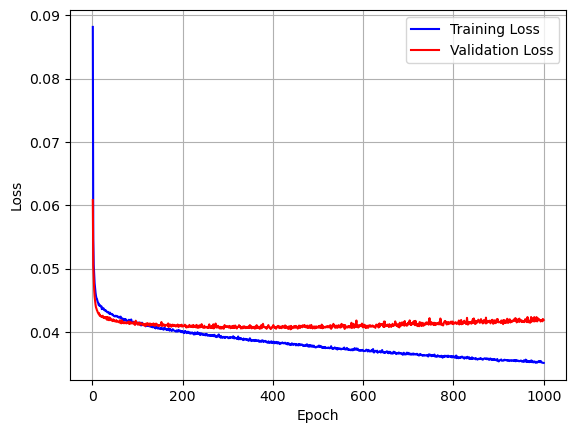

In [23]:
%%time
if generate_new_data:
    val_losses = []
    losses = []
    early_stopper = EarlyStopping()

    for num_epoch in range(1000):
        epoch_loss = 0
        total_batch = 0
        
        for batch_inputs, batch_labels in dataloader:
            train_x = batch_inputs.flatten(start_dim=1, end_dim=2).to(device)
            train_y = batch_labels.to(device)
            
            outputs = model(train_x)
            loss = criterion(outputs, train_y)
            epoch_loss += loss.item()
            total_batch += 1

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        val_x = inputs_val.flatten(start_dim=1, end_dim=2).to(device)
        val_y = labels_val.to(device)

        model.eval()
        with torch.no_grad():
            val_output = model(val_x)
            val_loss = criterion(val_output, val_y)
        
        val_losses.append(val_loss.item())
        early_stopper(val_loss)

        if (num_epoch + 1) % 100 == 0:
            print(f"Training is {int((num_epoch + 1) / 10)}% done, with Loss = {val_loss:.2f}")

        losses.append(epoch_loss / total_batch)

    plt.plot(np.arange(1, len(losses) + 1), losses, color="blue", label="Training Loss")
    plt.plot(np.arange(1, len(val_losses) + 1), val_losses, color="red", label="Validation Loss")
    plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid()

    torch.save(model.state_dict(), f"{output_dir}/model_weights.pth")


## Evaluate Reconstruction

In [24]:
model.load_state_dict(torch.load(f"{output_dir}/model_weights.pth"))

model.eval()
with torch.no_grad():
    outputs = model(inputs_test.view(Ntest, -1).to(device)).cpu()

In [25]:

# x_pred = outputs[:, 0]
# y_pred = outputs[:, 1]
E_pred, theta_pred, phi_pred = DenormalizeLabels(outputs[:, 0], outputs[:, 1], outputs[:, 2])
E_lb, theta_lb, phi_lb = DenormalizeLabels(labels_test[:, 0], labels_test[:, 1], labels_test[:, 2])

E_p,    E_r     =   E_pred,       E_lb
Th_p,   Th_r    =   theta_pred,   theta_lb
Ph_p,   Ph_r    =   phi_pred,     phi_lb

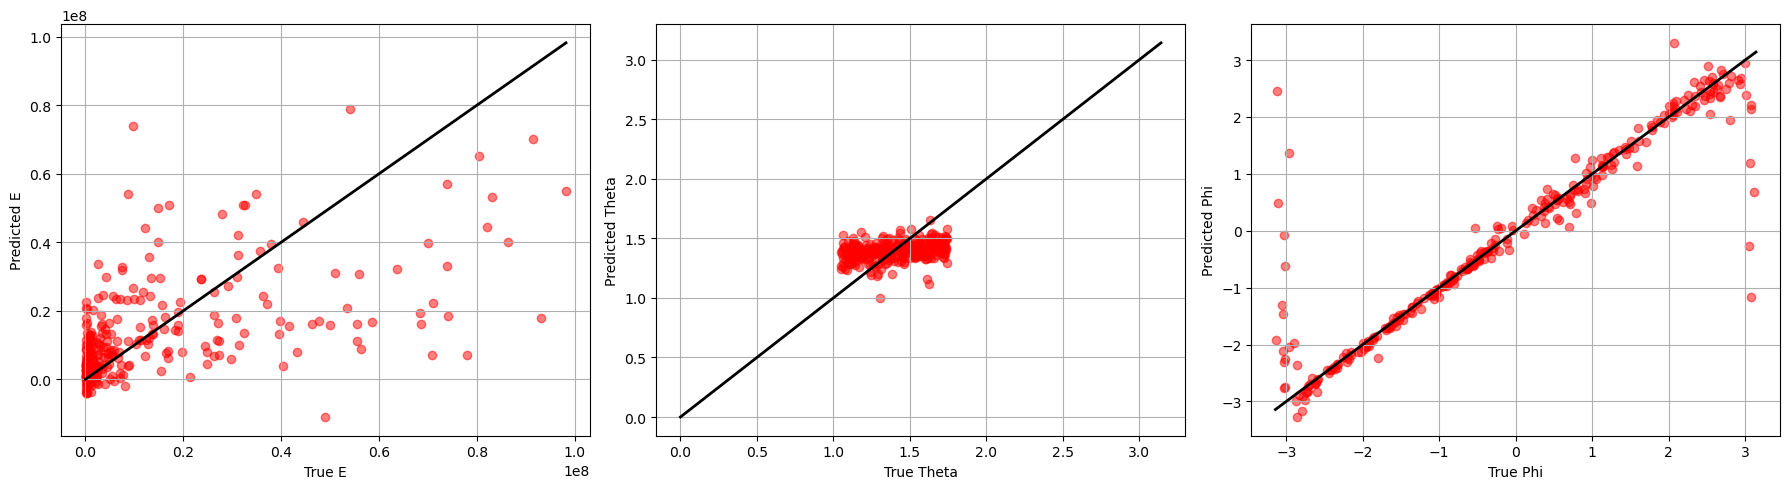

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(E_r.cpu(), E_p.cpu(), alpha=.5, color="r")
axes[0].plot([0, E_r.max().cpu()], [0, E_r.max().cpu()], "k-", lw=2)
axes[0].set_xlabel("True E"); axes[0].set_ylabel("Predicted E"); axes[0].grid()

axes[1].scatter(Th_r.cpu(), Th_p.detach().cpu(), alpha=.5, color="r")
axes[1].plot([0, np.pi], [0, np.pi], "k-", lw=2)
axes[1].set_xlabel("True Theta"); axes[1].set_ylabel("Predicted Theta"); axes[1].grid()

axes[2].scatter(Ph_r.cpu(), Ph_p.detach().cpu(), alpha=.5, color="r")
axes[2].plot([-np.pi, np.pi], [-np.pi, np.pi], "k-", lw=2)
axes[2].set_xlabel("True Phi"); axes[2].set_ylabel("Predicted Phi"); axes[2].grid()

plt.tight_layout(); plt.show()


## Load/Initialize Model for Optimization

In [27]:
torch.save(model.state_dict(), f"{output_dir}/model_weights.pth")

model = Reconstruction(
    num_detectors=Nunits,
    ).to(device)

path = Path(f"{output_dir}/checkpoint.pth")
if path.exists():
    checkpoint = torch.load(f"{output_dir}/checkpoint.pth")
    model.load_state_dict(checkpoint['model_state_dict'])
    print("Updated Weights are loaded")
else:
    model.load_state_dict(torch.load(f"{output_dir}/model_weights.pth"))
    print("Initial Weights are loaded")

Initial Weights are loaded


## Initialize Learnable Layout

In [28]:
e = 0
os.makedirs(f"{output_dir}/Python_Layout", exist_ok=True)

for i in range(1000):
    p_layout = Path(f"{output_dir}/Python_Layout/Layout_{i + 1}.txt")
    if p_layout.exists():
        data = np.loadtxt(p_layout)
        x_det = torch.tensor(data[:, 0], dtype=torch.float32)
        y_det = torch.tensor(data[:, 1], dtype=torch.float32)
        e = i + 1

if e > 0:
    print(f"Updated Layout {e} is initialized")
else:
    print("First Layout is initialized")

xy_module = LearnableXY(x_det, y_det, device=device)

First Layout is initialized


## Layout Optimization Loop

In [29]:
input_std = input_std.to(device)
input_mean = input_mean.to(device)

In [39]:
%%time

SWGOopt = True
optimizer = torch.optim.SGD(xy_module.parameters(), lr=10, momentum=.3)

if path.exists():
    checkpoint = torch.load(path)
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    num_epoch = checkpoint.get("epoch") + 1
    loss = checkpoint.get("loss")
    print(f"Optimizer is initialized from the last epoch {num_epoch}")
else:
    num_epoch = 0
    print("Optimizer is initialized")

# max_grad = 5. #10.
Nbatch = 500#1000

if num_epoch < 20:
    Nfinetune = 1250#2500
elif num_epoch >= 20:
    Nfinetune = 2500#5000

U_vals = []
U_th_vals = []
U_phi_vals = []
U_e_vals = []
U_pr_vals = []

for epoch in range(num_epoch, num_epoch + 200):
    x_det_opt, y_det_opt = xy_module()
    
    N_list, T_list, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(x_det_opt, y_det_opt, False, number_of_showers=Nbatch, use_cache=True)
    
    th = torch.atan2(sin_z, cos_z).to(device)
    ph = torch.atan2(sin_a, cos_a).to(device)

    X0 /= 5000
    Y0 /= 5000
    
    # detector locations            
    x_det_opt_exp = x_det_opt.unsqueeze(0).repeat(Nbatch, 1)
    y_det_opt_exp = y_det_opt.unsqueeze(0).repeat(Nbatch, 1)

    # shower centers    
    x0_exp = X0.unsqueeze(1).expand(-1, Nunits)
    y0_exp = Y0.unsqueeze(1).expand(-1, Nunits)

    inputs_batch = torch.stack([x_det_opt_exp, y_det_opt_exp, N_list, T_list, x0_exp, y0_exp], dim=2).float()
    with torch.no_grad():
        input_mean[0] = inputs_batch[:, :, 0].mean()
        input_mean[1] = inputs_batch[:, :, 1].mean()
        input_std[0]  = inputs_batch[:, :, 0].std().clamp(min=1e-8)
        input_std[1]  = inputs_batch[:, :, 1].std().clamp(min=1e-8)

    inputs_batch_norm = (inputs_batch - input_mean) / input_std

    model.eval()
    preds_batch = model(inputs_batch_norm.view(Nbatch, -1))

    preds_e, preds_th, preds_phi = DenormalizeLabels(preds_batch[:, 0], preds_batch[:, 1], preds_batch[:, 2])

    # compute utility 
    r_score = reconstructability(inputs_batch[:, :, 2], reconstruct_threshold=10)
    U = (
        1e2    *   U_angle( preds_th, th, r_score ) + 
        1e2    *   U_angle( preds_phi, ph, r_score ) +
        1e3     *   U_E( preds_e, energy, r_score ) + 
        # 1e9*N_list.mean()
        # 1e9*preds_e.mean()
        5e5     *   U_PR( r_score ) 
    ) / 1e3

    # save utlity values for logging
    U_vals.append( U.item() )
    U_th_vals.append( 1e2 * U_angle( preds_th, th, r_score ).item() )
    U_phi_vals.append( 1e2 * U_angle( preds_phi, ph, r_score ).item() )
    U_e_vals.append( 1e3 * U_E( preds_e, energy, r_score ).item() )
    U_pr_vals.append( ( 5e5 * U_PR( r_score ) ).item() )

    print(f"Utility: {U:.2f}")

    # backpropagate loss
    Loss = -U
    Loss.backward()

    for name, p in xy_module.named_parameters():
        print(f"{name}: grad norm = {p.grad.norm().item() if p.grad is not None else 'None'}")

    # torch.nn.utils.clip_grad_norm_(xy_module.parameters(), max_norm=max_grad)
    optimizer.step()

    # with torch.no_grad():
    #     push_apart(xy_module, min_dist=2 * TankRadius)
    
    optimizer.zero_grad()
    
    # Fine-tune NN every 5 epochs
    if (epoch + 1) % 5 == 0:
        
        model.zero_grad()
        print(f"Fine Tune at epoch {epoch + 1}")
        
        # Prepare data
        with torch.no_grad():
            x_det_ft, y_det_ft = xy_module()
            x_ft = x_det_ft.detach()
            y_ft = y_det_ft.detach()

            N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(x_ft, y_ft, False, number_of_showers=Nfinetune, use_cache=True)
            
            theta = torch.atan2(sin_z, cos_z)
            phi = torch.atan2(sin_a, cos_a)
            
            energy_norm, theta_norm, phi_norm = NormalizeLabels(energy, theta, phi)
            X0 /= 5000
            Y0 /= 5000
            
            # normalized labels
            labels_finetune = torch.stack([ energy_norm, theta_norm, phi_norm], dim=1).float()
            
            # detector locations
            x_det_ft_exp = x_ft.unsqueeze(0).expand(Nfinetune, -1)
            y_det_ft_exp = y_ft.unsqueeze(0).expand(Nfinetune, -1)
            
            # shower centers
            x0_exp = X0.unsqueeze(1).expand(-1, Nunits)
            y0_exp = Y0.unsqueeze(1).expand(-1, Nunits)

            inputs_finetune = torch.stack([x_det_ft_exp, y_det_ft_exp, N, T, x0_exp, y0_exp], dim=2).float()
            
            input_mean[0] = inputs_finetune[:, :, 0].mean()
            input_mean[1] = inputs_finetune[:, :, 1].mean()
            input_std[0]  = inputs_finetune[:, :, 0].std().clamp(min=1e-8)
            input_std[1]  = inputs_finetune[:, :, 1].std().clamp(min=1e-8)

            inputs_finetune = (inputs_finetune - input_mean) / input_std

        # get model
        ReconstructionNN = model
        ReconstructionNN.train()
        criterion = nn.MSELoss()
        optimizerNN = torch.optim.Adam(ReconstructionNN.parameters(), lr=1e-6)
        
        # create training dataset
        ft_dataset = TensorDataset(inputs_finetune, labels_finetune)
        ft_dataloader = DataLoader(ft_dataset, batch_size=32, shuffle=True, drop_last=True, num_workers=0)

        # train NN for 5 sub-epochs
        for j in range(2):
            for inputs_ft, labels_ft in ft_dataloader:
                batch_size = inputs_ft.size(0)
                train_x = inputs_ft.view(batch_size, -1).to(device)
                train_y = labels_ft.view(batch_size, 3).to(device)
                outputs = ReconstructionNN(train_x)
                lossT = criterion(outputs, train_y)
                lossT.backward()
                optimizerNN.step()
                optimizerNN.zero_grad()

    torch.save({"epoch": epoch, "loss": Loss.cpu(), "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict()}, f"{output_dir}/checkpoint.pth")
    
    np.savetxt(f"{output_dir}/Python_Layout/Layout_{epoch + 1}.txt",
               np.column_stack((x_det_opt.detach().cpu().numpy(), y_det_opt.detach().cpu().numpy())))

Optimizer is initialized from the last epoch 100
Loading cached showers from ./outputs/NN_Files_31_20k_small_start/cashed_showers_500.pt
Utility: 31050.77
x: grad norm = 24.371150970458984
y: grad norm = 19.927940368652344
Loading cached showers from ./outputs/NN_Files_31_20k_small_start/cashed_showers_500.pt
Utility: 31652.48
x: grad norm = 23.240819931030273
y: grad norm = 22.044769287109375
Loading cached showers from ./outputs/NN_Files_31_20k_small_start/cashed_showers_500.pt
Utility: 32514.14
x: grad norm = 30.10072898864746
y: grad norm = 29.40420913696289
Loading cached showers from ./outputs/NN_Files_31_20k_small_start/cashed_showers_500.pt
Utility: 28382.06
x: grad norm = 31.467649459838867
y: grad norm = 29.71718978881836
Loading cached showers from ./outputs/NN_Files_31_20k_small_start/cashed_showers_500.pt
Utility: 30693.62
x: grad norm = 25.69807243347168
y: grad norm = 20.92848777770996
Fine Tune at epoch 105
  Loading PointCountFM from /n/home05/zdimitrov/tambo/TAMBO-opt

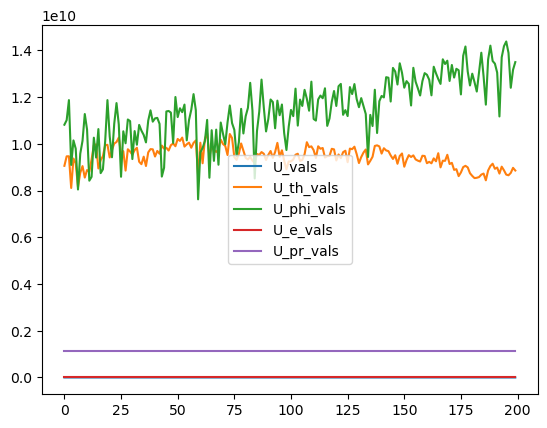

In [40]:
plt.plot(U_vals, label='U_vals')
plt.plot([1000*u for u in U_th_vals], label='U_th_vals')
plt.plot([1000*u for u in U_phi_vals], label='U_phi_vals')
plt.plot(U_e_vals, label='U_e_vals')
plt.plot([100*u for u in U_pr_vals], label='U_pr_vals')
plt.legend()

## Visualize Results

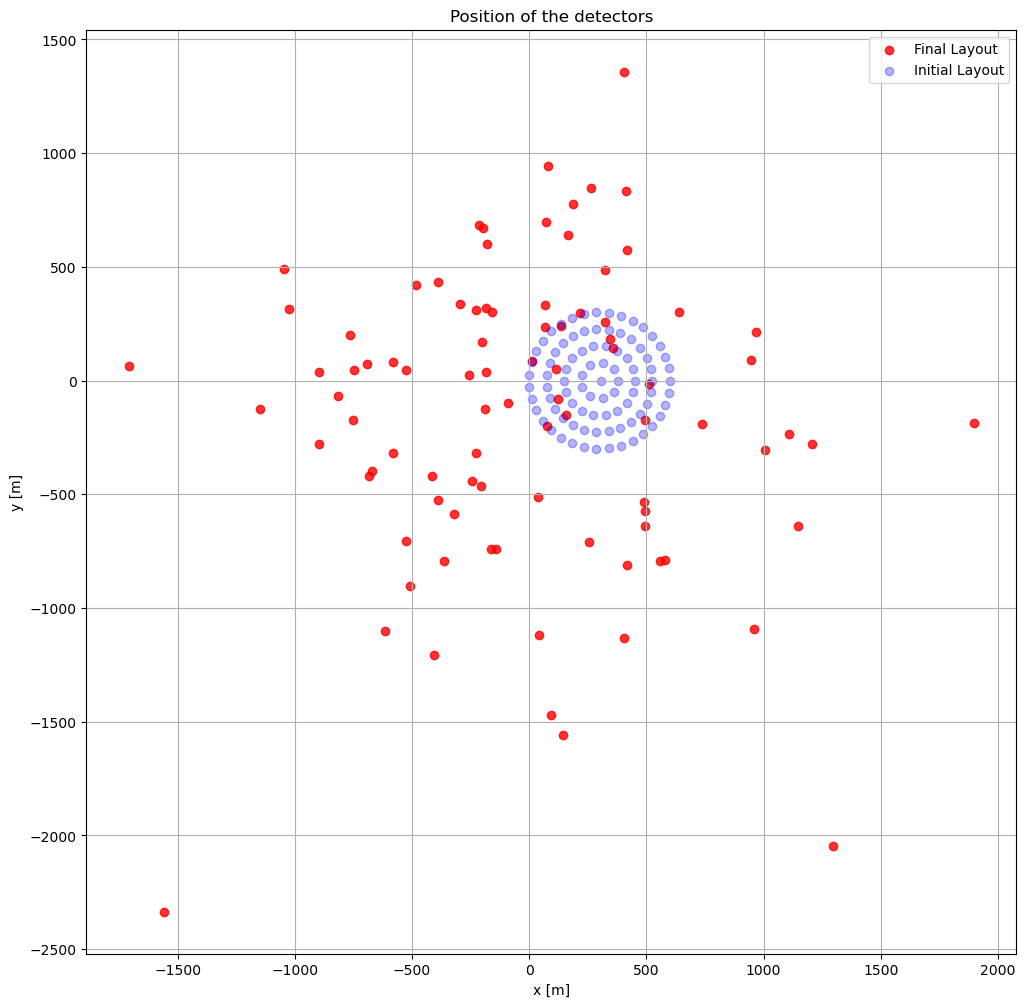

In [41]:
a, b = Layouts(n_detectors=Nunits, n_rings=n_rings, radius=300)

plt.figure(figsize=[12, 12])
plt.scatter(
    x_det_opt.detach().cpu(), 
    y_det_opt.detach().cpu(), 
    color="red", alpha=.8, label="Final Layout"
    )
plt.scatter(a, b, color="blue", alpha=.3, label="Initial Layout")
plt.grid(); plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.title("Position of the detectors"); plt.legend()
plt.show()

In [42]:
utility_path = Path(f"{output_dir}/Python_Layout/Utilities.txt")

if utility_path.exists():
    u_t = np.loadtxt(utility_path)
    u_t = np.append(u_t, np.array(U_vals).ravel())
    np.savetxt(utility_path, u_t)
else:
    u_t = U_vals
    np.savetxt(utility_path, u_t)

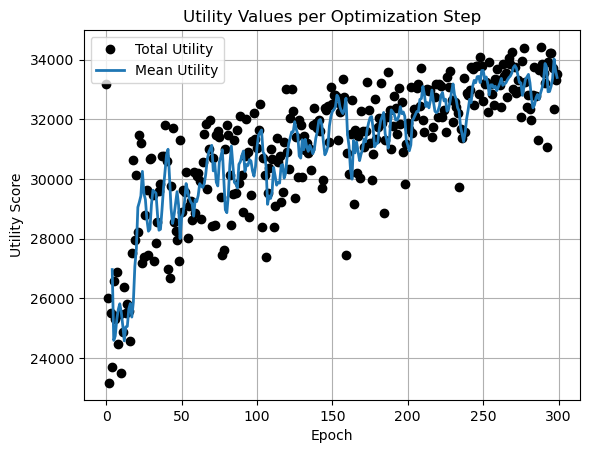

In [43]:
mean_ut = [np.mean(u_t[i - 4: i]) for i in range(4, len(u_t))]

plt.plot(u_t, color="black", linestyle="none", marker="o", linewidth=.5, label="Total Utility")
plt.plot(np.arange(4, len(u_t)), mean_ut, linestyle="-", linewidth=2, label="Mean Utility")
plt.legend(); plt.grid()
plt.xlabel("Epoch"); plt.ylabel("Utility Score")
# plt.ylim((-0.1, 1000.2))
plt.title("Utility Values per Optimization Step")
plt.show()

## Evaluate Reconstruction (end)

In [35]:
x,y = x_det_opt,y_det_opt
with torch.no_grad():
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(x, y, False, number_of_showers=Ntest, use_cache=True)

th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
x0 = X0 / 5000
y0 = Y0 / 5000

x_exp = x.unsqueeze(0).expand(Ntest, -1)
y_exp = y.unsqueeze(0).expand(Ntest, -1)

x0_exp = x0.unsqueeze(1).expand(-1, Nunits)
y0_exp = y0.unsqueeze(1).expand(-1, Nunits)

inputs_test = torch.stack([x_exp, y_exp, N, T, x0_exp, y0_exp], dim=2).float()
inputs_test = (inputs_test - input_mean) / input_std  # add this line
labels_test = torch.stack([E_norm, theta_norm, phi_norm], dim=1).float()

Loading cached showers from ./outputs/NN_Files_31_20k_small_start/cashed_showers_300.pt


In [36]:
model.eval()
with torch.no_grad():
    outputs = model(inputs_test.view(Ntest, -1).to(device)).cpu()

In [37]:
E_pred, theta_pred, phi_pred = DenormalizeLabels(outputs[:, 0], outputs[:, 1], outputs[:, 2])

E_p, E_r = E_pred.cpu(), energy.cpu()
Th_r, Th_p = th.cpu(), theta_pred.cpu()
Ph_r, Ph_p = ph.cpu(), phi_pred.cpu()

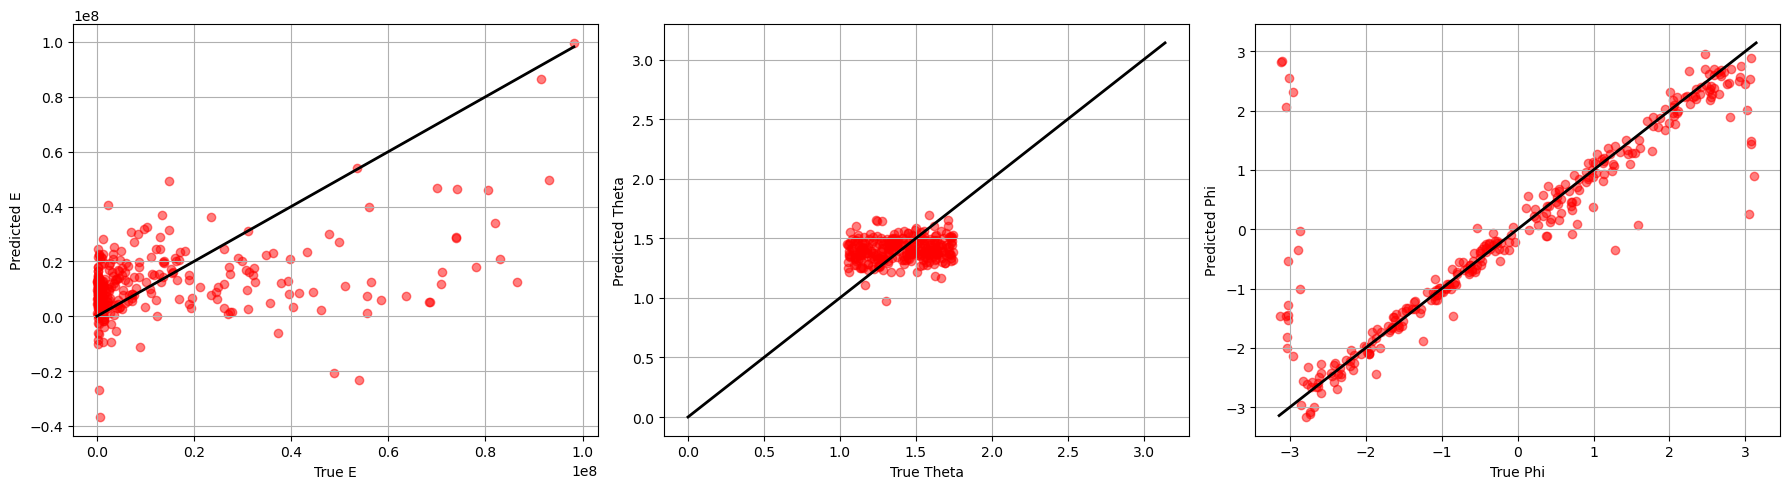

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(E_r.cpu(), E_p.cpu(), alpha=.5, color="r")
axes[0].plot([0, E_r.max().cpu()], [0, E_r.max().cpu()], "k-", lw=2)
axes[0].set_xlabel("True E"); axes[0].set_ylabel("Predicted E"); axes[0].grid()

axes[1].scatter(Th_r.cpu(), Th_p.detach().cpu(), alpha=.5, color="r")
axes[1].plot([0, np.pi], [0, np.pi], "k-", lw=2)
axes[1].set_xlabel("True Theta"); axes[1].set_ylabel("Predicted Theta"); axes[1].grid()

axes[2].scatter(Ph_r.cpu(), Ph_p.detach().cpu(), alpha=.5, color="r")
axes[2].plot([-np.pi, np.pi], [-np.pi, np.pi], "k-", lw=2)
axes[2].set_xlabel("True Phi"); axes[2].set_ylabel("Predicted Phi"); axes[2].grid()

plt.tight_layout(); plt.show()


TAMBO KPI
- efficiency, fraction of particles detected, 
- they don't care about Energy
- direction of the primary particle